In [16]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import re

options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
options.add_argument("--disable-blink-features=AutomationControlled")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

BASE_URL = "https://www.vigloo.com/ko?tab=categories"


def scroll_once(pause=1.0):
    try:
        container = driver.find_element(By.ID, "desktop-scroll-container")
        driver.execute_script(
            "arguments[0].scrollTop = arguments[0].scrollHeight;",
            container
        )
    except:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

    time.sleep(pause)


def load_cards_until(target_idx, max_scrolls=6, pause=0.8):
    for _ in range(max_scrolls):
        cards = driver.find_elements(By.CSS_SELECTOR, "div.vds-bundle-card")

        if len(cards) > target_idx:
            return cards

        scroll_once(pause)

    return driver.find_elements(By.CSS_SELECTOR, "div.vds-bundle-card")


def get_card_info(card):
    title = ""
    tags = ""

    h3 = card.find_elements(By.CSS_SELECTOR, "h3")
    if h3:
        title = h3[0].text.strip()

    p = card.find_elements(By.CSS_SELECTOR, "p")
    if p:
        tags = p[0].text.strip()

    return title, tags


def get_total_episode(body_text):
    ranges = re.findall(r"\d+\s*-\s*\d+(?:\(완결\))?", body_text)

    if ranges:
        nums = re.findall(r"\d+", " ".join(ranges))
        return max(map(int, nums))

    nums = re.findall(r"\n(\d{1,3})\n", body_text)
    if nums:
        return max(map(int, nums))

    return ""


def get_synopsis_from_detail():
    ps = driver.find_elements(By.CSS_SELECTOR, "p.text-gray-white")
    candidates = []

    for p in ps:
        txt = p.text.strip()

        if (
            len(txt) >= 30
            and "멤버십 구독" not in txt
            and "무제한 시청하기" not in txt
            and "비슷한 콘텐츠" not in txt
            and "에피소드" not in txt
            and "주소:" not in txt
            and "VIGLOO" not in txt
        ):
            candidates.append(txt)

    return max(candidates, key=len) if candidates else ""


def get_genre_from_detail():
    spans = driver.find_elements(By.CSS_SELECTOR, "span.text-gray-400")
    genre_list = []

    for span in spans:
        txt = span.text.strip()

        if txt and len(txt) <= 10 and txt not in genre_list:
            genre_list.append(txt)

    return " · ".join(genre_list)


def get_country_from_detail():
    countries = ["한국", "미국", "일본", "중국", "태국", "기타"]

    spans = driver.find_elements(By.CSS_SELECTOR, "span.text-gray-400")

    for span in spans:
        txt = span.text.strip()

        if txt in countries:
            return txt

    return ""


print("=" * 50)
print("STEP 1 : 카드 목록 수집")
print("=" * 50)

driver.get(BASE_URL)
time.sleep(3)

for i in range(4):
    scroll_once(1.2)
    cards = driver.find_elements(By.CSS_SELECTOR, "div.vds-bundle-card")
    print(f"스크롤 {i + 1}회 | 카드 수: {len(cards)}")

cards = driver.find_elements(By.CSS_SELECTOR, "div.vds-bundle-card")
total_cards = len(cards)

item_list = []

for idx, card in enumerate(cards):
    title, tags = get_card_info(card)

    item_list.append({
        "순번": idx + 1,
        "제목": title,
        "태그/설명": tags
    })

print(f"\n최종 카드 수: {len(item_list)}")

results = []

print("\n" + "=" * 50)
print("STEP 2 : 상세 정보 수집")
print("=" * 50)

for item in item_list:
    idx = item["순번"] - 1
    title = item["제목"]
    tags = item["태그/설명"]

    print(f"[{item['순번']}/{len(item_list)}] {title}", end=" ... ")

    try:
        driver.get(BASE_URL)
        time.sleep(1.5)

        cards = load_cards_until(idx, max_scrolls=6, pause=0.8)

        if len(cards) <= idx:
            print("카드 없음")

            results.append({
                "순번": item["순번"],
                "제목": title,
                "태그/설명": tags,
                "국가": "",
                "장르": "",
                "줄거리": "",
                "총회차": "",
                "URL": ""
            })
            continue

        card = cards[idx]

        try:
            click_target = card.find_element(By.CSS_SELECTOR, "div.vds-relative")
        except:
            click_target = card

        driver.execute_script(
            "arguments[0].scrollIntoView({block:'center'});",
            click_target
        )
        time.sleep(0.3)

        driver.execute_script("arguments[0].click();", click_target)
        time.sleep(2)

        detail_url = driver.current_url

        if "/video/" not in detail_url:
            print("이동 실패")

            results.append({
                "순번": item["순번"],
                "제목": title,
                "태그/설명": tags,
                "국가": "",
                "장르": "",
                "줄거리": "",
                "총회차": "",
                "URL": detail_url
            })
            continue

        body_text = driver.find_element(By.TAG_NAME, "body").text

        country = get_country_from_detail()
        genre = get_genre_from_detail()
        synopsis = get_synopsis_from_detail()
        total_episode = get_total_episode(body_text)

        results.append({
            "순번": item["순번"],
            "제목": title,
            "태그/설명": tags,
            "국가": country,
            "장르": genre,
            "줄거리": synopsis,
            "총회차": total_episode,
            "URL": detail_url
        })

        print(detail_url)

    except Exception as e:
        print(f"오류: {e}")

        results.append({
            "순번": item["순번"],
            "제목": title,
            "태그/설명": tags,
            "국가": "",
            "장르": "",
            "줄거리": "",
            "총회차": "",
            "URL": ""
        })

    if len(results) % 20 == 0:
        temp_df = pd.DataFrame(results)
        temp_df.to_csv("vigloo_temp.csv", index=False, encoding="utf-8-sig")


df = pd.DataFrame(results)

df.to_csv("vigloo_all_works.csv", index=False, encoding="utf-8-sig")
df.to_excel("vigloo_all_works.xlsx", index=False)

print("\n" + "=" * 50)
print("수집 완료")
print(f"총 저장 작품 수: {len(df)}개")
print("저장 파일: vigloo_all_works.csv / vigloo_all_works.xlsx")
print("=" * 50)

print(df.head())

driver.quit()

STEP 1 : 카드 목록 수집
스크롤 1회 | 카드 수: 90
스크롤 2회 | 카드 수: 150
스크롤 3회 | 카드 수: 197
스크롤 4회 | 카드 수: 197

최종 카드 수: 197

STEP 2 : 상세 정보 수집
[1/197] 천재 아기의 인생 역전 ... https://www.vigloo.com/ko/video/15001849?episode=1
[2/197] 수상한 남편의 이중생활 ... https://www.vigloo.com/ko/video/15001753?episode=1
[3/197] 닿을 수 있는 그녀 ... https://www.vigloo.com/ko/video/15001453?episode=1
[4/197] 모쏠지옥 ... https://www.vigloo.com/ko/video/15001786?episode=1
[5/197] 비서할래 와이프할래? ... https://www.vigloo.com/ko/video/15001355?episode=1
[6/197] 뚱보 아내는 조폭 마누라 ... https://www.vigloo.com/ko/video/15001651?episode=1
[7/197] 국가권력급 상속자가 돌아왔다 ... https://www.vigloo.com/ko/video/15001189?episode=1
[8/197] 타임리프 로맨스: 은밀한 복수 ... https://www.vigloo.com/ko/video/15000140?episode=1
[9/197] 오늘 한류스타와 이혼하겠습니다 ... https://www.vigloo.com/ko/video/15000826?episode=1
[10/197] 장녀 결혼 일기 ... https://www.vigloo.com/ko/video/15000728?episode=1
[11/197] 그 여자를 유혹해줘 ... https://www.vigloo.com/ko/video/15001717?episode=1
[12/197] D-100 : 남편을 리셋합니다 ... https://ww

In [1]:
import pandas as pd

df = pd.read_csv("vigloo_all_works.csv")

# 줄거리, 장르 없는 거 제거
df = df.dropna(subset=["장르", "줄거리"])

df

,순번,제목,태그/설명,국가,장르,줄거리,총회차,URL
0,1,천재 아기의 인생 역전,참교육,NaN,환생· · 반전· · 사이다,친부와 새엄마 때문에 억울한 누명을 쓰고 교도소에서 숨진 도혁. 눈을 떠보니 201...,76.0,https://www.vigloo.com/ko/video/15001849?episo...
1,2,수상한 남편의 이중생활,로맨틱한,NaN,로맨스· · 재벌· · 반전,"재벌가 후계자 자리를 박차고 나와 택시기사, 정육점, 택배기사로 ‘쓰리 잡’을 뛰며...",72.0,https://www.vigloo.com/ko/video/15001753?episo...
2,3,닿을 수 있는 그녀,초고속결혼,NaN,로맨스· · 재벌· · 사이다,강씨 가문의 양녀 강유진은 가족의 지시로 향한 호텔에서 여자 알러지가 있는 성원그룹...,81.0,https://www.vigloo.com/ko/video/15001453?episo...
3,4,모쏠지옥,고자극,NaN,로맨스· · 리얼리티· · 드라마,"친구에게 속아 연애서바이벌 <핫연애존>에 입주한 솔지, 쉴 틈 없이 이어지는 고자극...",53.0,https://www.vigloo.com/ko/video/15001786?episo...
4,5,비서할래 와이프할래?,선결혼후연애,NaN,로맨스· · 코미디,할머니 수술비가 필요했던 박하은은 1년간 결혼 신분을 빌려주는 계약 결혼을 하기로 ...,80.0,https://www.vigloo.com/ko/video/15001355?episo...
...,...,...,...,...,...,...,...,...
192,193,미워할 수 없는 나의 라이벌,언더커버,NaN,로맨스· · 혐관· · 정치,대담한 정치 전략가 클로이 하퍼는 선거 유세 현장에서 라이벌 트래비스 콜과 충돌한다...,49.0,https://www.vigloo.com/ko/video/15000167?episo...
193,194,그녀를 사랑한 대가,복수,NaN,로맨스· · 배신· · 사이다,소설가 앨릭스 크로는 무자비한 헥터 크루즈와의 해로운 결혼 생활에 갇힌 아름다운 여...,48.0,https://www.vigloo.com/ko/video/15000152?episo...
194,195,큐의 단죄,서스펜스,NaN,스릴러· · 호러· · 삼각관계,행복한 소마 일가 앞에 갑자기 나타난 수수께끼의 인물 큐타로. 소마 일가의 일상에 ...,49.0,https://www.vigloo.com/ko/video/15000163?episo...
195,196,일주일간의 동거,로맨틱한,NaN,혐관· · 삼각관계· · 로맨스,극과 극인 두 사람이 일주일간 같은 집에서 살게 된다. 엉망진창이었던 그들의 생활은...,49.0,https://www.vigloo.com/ko/video/15000499?episo...


In [3]:
# 장르 분리
df["장르"] = df["장르"].str.replace(" ", "")
df["장르리스트"] = df["장르"].str.split("·")

# explode로 행 펼치기
genre_df = df.explode("장르리스트")

# 빈값 제거
genre_df = genre_df[genre_df["장르리스트"] != ""]

# 장르별 개수
genre_count = genre_df["장르리스트"].value_counts()

print(genre_count)

장르리스트
로맨스       137
재벌         43
사이다        34
드라마        29
판타지        28
반전         26
코미디        23
운명         23
삼각관계       20
찐사랑        18
배신         18
치정         16
혐관         14
스릴러        13
재회         10
다정남         9
환생          9
로코          7
금지된사랑       7
언더커버        7
리얼리티        6
미스터리        6
하이틴         5
시대극/사극      4
초고속결혼       3
로판          3
늑대인간        3
뱀파이어        3
호러          3
이혼          3
SF          3
고자극         3
연상연하        3
걸크러쉬        3
순애          3
CEO         2
액션          2
계약연애        2
애니메이션       1
아이돌         1
친구>연인       1
신분상승        1
정치          1
Name: count, dtype: int64


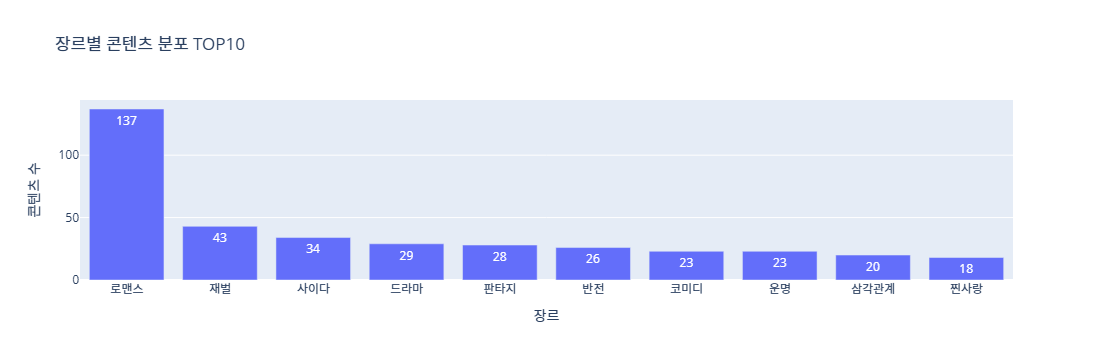

In [4]:
import plotly.express as px

top10 = genre_count.head(10)

fig = px.bar(
    x=top10.index,
    y=top10.values,
    labels={"x": "장르", "y": "콘텐츠 수"},
    title="장르별 콘텐츠 분포 TOP10",
    text=top10.values
)

fig.show()

In [27]:
import pandas as pd

df = pd.read_csv("vigloo_all_works.csv")

# 숫자로 변환
df["총회차"] = pd.to_numeric(df["총회차"], errors="coerce")

# 전체 평균
avg_episode = df["총회차"].mean()

print(f"전체 평균 회차: {avg_episode:.2f}")

전체 평균 회차: 52.43


In [28]:
# 장르 정리
df["장르"] = df["장르"].str.replace(" ", "")
df["장르리스트"] = df["장르"].str.split("·")

# 펼치기
genre_df = df.explode("장르리스트")

# 빈값 제거
genre_df = genre_df[genre_df["장르리스트"] != ""]

In [6]:
genre_avg = (
    genre_df
    .groupby("장르리스트")["총회차"]
    .mean()
    .sort_values(ascending=False)
)

print(genre_avg.head(10))

장르리스트
사이다       59.029412
시대극/사극    58.750000
걸크러쉬      58.333333
친구>연인     58.000000
환생        57.777778
반전        57.269231
로판        56.333333
혐관        55.928571
재벌        55.558140
언더커버      54.142857
Name: 총회차, dtype: float64


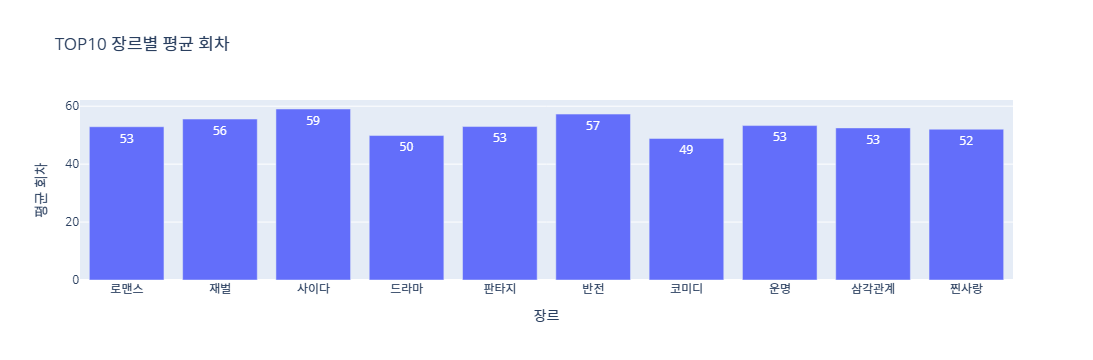

In [14]:
import plotly.express as px

# 1. 장르 개수 TOP10
top_genres = genre_count.head(10).index

# 2. 그 장르들의 평균 회차
top10_avg = genre_avg.loc[top_genres]

# 3. 시각화
fig = px.bar(
    x=top10_avg.index,
    y=top10_avg.values,
    labels={"x": "장르", "y": "평균 회차"},
    title="TOP10 장르별 평균 회차",
    text=top10_avg.values 
)

fig.update_traces(texttemplate='%{text:.0f}')

fig.show()

In [9]:
# 공백 제거 + 분리
df["태그/설명"] = df["태그/설명"].str.replace(" ", "")
df["태그리스트"] = df["태그/설명"].str.split("·")

# explode
tag_df = df.explode("태그리스트")

# 빈값 제거
tag_df = tag_df[tag_df["태그리스트"] != ""]

tag_count = tag_df["태그리스트"].value_counts()

top10_tags = tag_count.head(10)

print(top10_tags)

태그리스트
언더커버     16
복수       14
로코       13
재벌       11
비밀신분      9
청춘물       6
나이차이      6
계약결혼      6
금지된사랑     5
삼각관계      5
Name: count, dtype: int64


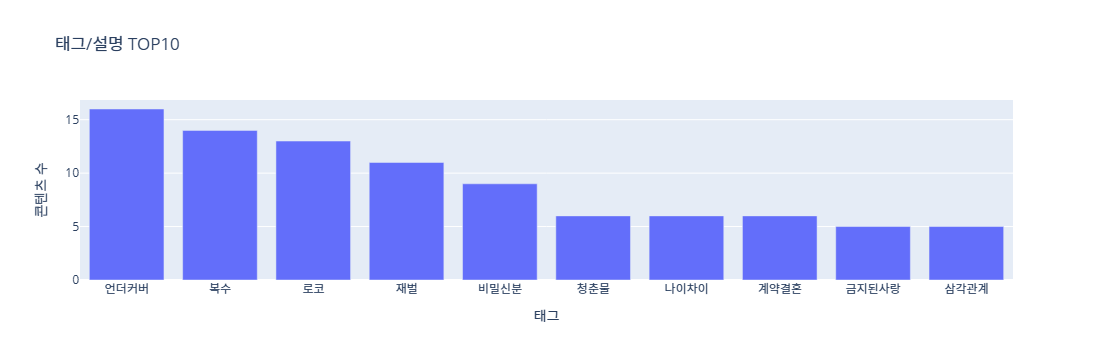

In [11]:
import plotly.express as px

fig = px.bar(
    x=top10_tags.index,
    y=top10_tags.values,
    labels={"x": "태그", "y": "콘텐츠 수"},
    title="태그/설명 TOP10"
)

fig.show()